# NOTE ON USAGE AND CONTEXT

This script accompanies the scientific work:
"Primordial Black Holes as Cosmic Architects: Imprints of an extended mass function"
(Magaraggia et al. 2026) 

It implements the full computational pipeline used in the paper, including:
- construction of the PBH mass function and its physical normalization,
- computation of the matter power spectrum and its PBH contribution,
- derivation of the halo mass function and star formation rate density,
- modeling of reionization and Thomson optical depth,
- calculation of PBH merger rates and their detectability by LVK and LISA.

The code is provided as open-source under the MIT License.

If you use this script, or any part or modification of it, in your work,
please cite the associated paper listed above. Proper citation is required
to acknowledge the scientific framework, assumptions, and methodology
implemented here.

The script is intended for reproducibility and further exploration of the
results presented in the paper, and users are encouraged to adapt and extend
it within the scope of their research.


### Files required by the script

1. `FA2.txt`  
   Main PBH mass function to be tested.  
   Format: two lines, with `x=[...]` on the first line containing the mass values, and `y=[...]` on the second line containing \($ df/d\ln M $\).

2. `Hasinger.txt`  
   Reference PBH mass function, used when a comparison is needed.  
   Format: two lines, with `x=[...]` on the first line containing the mass values, and `y=[...]` on the second line containing \($ df/d\ln M $\).

3. `O3-H1.txt`  
   LIGO O3b sensitivity curve in ASD form.  
   Format: two columns, with frequency in Hz in the first column and ASD in \($ \mathrm{Hz}^{-1/2} $ \) in the second column.

4. `LISA_ASD.txt`  
   LISA sensitivity curve in ASD form.  
   Format: two columns, with frequency in Hz in the first column and ASD in \($ \mathrm{Hz}^{-1/2} $ \) in the second column.

5. `SFRs.csv`  
   Literature compilation of the cosmic star formation rate density, updated to 2026.  
   Format: six columns:  
   `z_best`, `z_err_plus`, `z_err_minus`, `log_SFRD`, `log_SFRD_err_plus`, `log_SFRD_err_minus`.

6. `xi_values.csv`  
   Literature compilation of the reionization history, updated to 2026.  
   Format: six columns:  
   `z_best`, `z_err_plus`, `z_err_minus`, `xi_best`, `xi_err_plus`, `xi_err_minus`.

7. `event_versions.xlsx`  
   Compilation of gravitational-wave event component masses, updated to 2026.  
   Format: eight columns:  
   `event_name`, `catalog_name`, `mass_1_source`, `mass_1_source_lower`, `mass_1_source_upper`, `mass_2_source`, `mass_2_source_lower`, `mass_2_source_upper`.

8. figurepaper/  
Output directory where figures are saved. This folder must exist prior to execution.

Notes:
- Mass function files must use Python list syntax (x=[...], y=[...]) compatible with ast.literal_eval.
- Noise curves must cover the full frequency range used in the integrals to avoid extrapolation errors.
- The script assumes a fixed cosmology (Planck 2020 parameters) defined globally (see the corresponding section).
- Required Python packages: see next section

## Python packages

In [ ]:
# RUNS ON PYTHON 3.10.12
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import gamma, hyperu
from scipy.integrate import quad, simpson
from scipy.interpolate import UnivariateSpline
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import cumulative_trapezoid
from cosmolopy.perturbation import power_spectrum, fgrowth

/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Cosmology and standard physical parameters
Note: Model-dependent parameters are defined in the corresponding sections, not here

In [ ]:
# Define the physical constants and unit-conversion factors used throughout the notebook,
# including SI and cgs versions of G and c, standard cosmological distance conversions,
# the Thomson cross section, and the solar mass.

# ── PHYSICAL CONSTANTS ───────────────────────────────────────────────────────
pi = 3.141593
KM = 1e3                                           # m
MPC = 3.085677581e22                               # m
SEC_PER_YR = 365.25 * 24 * 3600.0                  # s/yr
G      = 6.6743e-11                                # m^3 kg^-1 s^-2
G_cgs  = G * 1e3                                   # cm^3 g^-1 s^-2
c = 299792458                                      # m/s
c_cgs  = c * 1e2                                   # cm/s
c_kms =  c / 1e3                                   # km/s
Mpc2cm   = 3.08567758e24                           # cm/Mpc
sigma_T  = 6.6524587e-25                           # Thomson scattering cross-section, cm^2
Msun   = 1.98847e33                                # g



# Collect the fiducial cosmological parameters adopted in the analysis, including the
# dimensionless Hubble parameter, present-day matter, baryon, and dark-energy densities.

# ─── SINGLE COSMOLOGY DEFINITION ────────────────────────────────────────────
cosmology = {
    'h':               0.6766,
    'omega_M_0':       0.30966,
    'omega_b_0':       0.04897,
    'omega_lambda_0':  0.6889,
    'omega_n_0':       0.0,
    'sigma_8':         0.8102,
    'n':               0.9665,
    'N_nu':            3,
    'baryonic_effects':False,
}

h      = cosmology['h']
Om     = cosmology['omega_M_0']
Ob     = cosmology['omega_b_0']
Ov     = cosmology['omega_lambda_0']
sigma8 = cosmology['sigma_8']
Omega_dm = Om - Ob

H0 = 100. * h / 3.085e19                                                    # s^-1   
H0_kms_Mpc = cosmology['h'] * 100                                           # km/s/Mpc 
rho_cr = (3 * (100*h)**2 / (8 * np.pi * G)) * 1e6 * 5.027e-31 / (3.24e-23)  # critical density, Solar masses / Mpc^3
rho_c = 3 * H0**2 / (8 * pi * G_cgs)                                        # critical density, g/cm^3
rhoDM = 0.26 * rho_c                                                        # DM density, g/cm^3

## PBH mass function 

In [ ]:
# ─────── The mass function is assumed to be df/dlnM ─────────────── 
# Read the tabulated PBH mass function from file, keep only the physical domain with
# positive mass and positive df/dlnM, and construct a smoothed spline in log-log space
# for interpolation of the distribution over the sampled mass range.

file_path = 'FA2.txt' 
mass_smooth_factor = 0.1  #adjust based on your mass file

with open(file_path, 'r') as f:
    lines = f.read().splitlines()

for line in lines:
    if line.lstrip().startswith('x'):
        x = ast.literal_eval(line.split('=', 1)[1])
    elif line.lstrip().startswith('y'):
        y = ast.literal_eval(line.split('=', 1)[1])

x = np.array(x, float)
y = np.array(y, float)
mask = (x > 0) & (y > 0)
x_pos, y_pos = x[mask], y[mask]

spline_log = UnivariateSpline(np.log10(x_pos), np.log10(y_pos), s=mass_smooth_factor)


# Repeat the same procedure for a second PBH mass-function file, using an independent
# smoothing choice to build a separate log-log spline representation for comparison.

file_path_1 = 'Hasinger.txt' 
mass_smooth_factor = 0.08  #adjust based on your mass file

with open(file_path_1, 'r') as f:
    lines = f.read().splitlines()

for line in lines:
    if line.lstrip().startswith('x'):
        x = ast.literal_eval(line.split('=', 1)[1])
    elif line.lstrip().startswith('y'):
        y = ast.literal_eval(line.split('=', 1)[1])

x = np.array(x, float)
y = np.array(y, float)
mask1 = (x > 0) & (y > 0)
x_pos1, y_pos1 = x[mask1], y[mask1]

spline_log1 = UnivariateSpline(np.log10(x_pos1), np.log10(y_pos1), s=mass_smooth_factor)


def mass_fn(M):
    return 10**spline_log(np.log10(M))

# Determine the valid mass interval covered by the first input mass function, sample it on
# a logarithmic grid, evaluate both spline reconstructions, and estimate the integrated PBH
# fraction f_PBH by numerically integrating (df/dlnM)/M over mass.

M_min, M_max = x_pos.min(), x_pos.max()
print(f"M_min = {M_min:.2e}, M_max = {M_max:.2e}")

M_plot = np.logspace(np.log10(M_min), np.log10(M_max), 1000)
df_PBH = 10**spline_log(np.log10(M_plot))

M_plot1 = np.logspace(np.log10(M_min), np.log10(M_max), 1000)
df_PBH1 = 10**spline_log1(np.log10(M_plot1))

f_pbh = simpson(df_PBH/M_plot,x=M_plot)
print(f"Total f_PBH = {f_pbh:.3g}")

M_min = 1.00e-06, M_max = 4.00e+08
Total f_PBH = 0.339


#### Figure

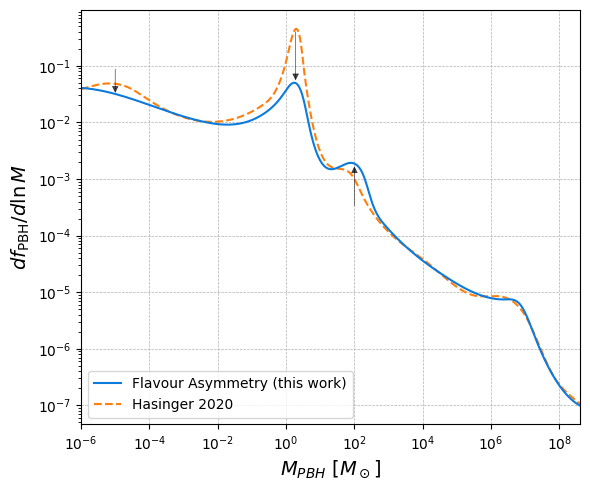

In [ ]:
# Compare the two spline-reconstructed PBH mass functions by first evaluating their amplitudes
# at selected masses, using these values to place vertical arrows that highlight where the
# distributions differ, and then plotting both df_PBH/dlnM curves on logarithmic axes.

plt.figure(figsize=(6, 5))

# --- compute y-values of both curves at M = 1.5 and 100 Msun ---
M_down1, M_down2, M_up = 1e-5, 1.9, 100.0

y_down_FA1  = 10**spline_log(np.log10(M_down1))
y_down_Has1 = 10**spline_log1(np.log10(M_down1))
y_down_FA2  = 10**spline_log(np.log10(M_down2))
y_down_Has2 = 10**spline_log1(np.log10(M_down2))
y_up_FA    = 10**spline_log(np.log10(M_up))
y_up_Has   = 10**spline_log1(np.log10(M_up))

# --- ensure correct ordering (so arrows go from top to bottom, or vice versa) ---
y_down_top1, y_down_bot1 = (y_down_Has1, y_down_FA1) if y_down_Has1 > y_down_FA1 else (y_down_FA1, y_down_Has1)
y_down_top2, y_down_bot2 = (y_down_Has2, y_down_FA2) if y_down_Has2 > y_down_FA2 else (y_down_FA2, y_down_Has2)
y_up_top,   y_up_bot   = (y_up_Has,   y_up_FA)   if y_up_Has   > y_up_FA   else (y_up_FA,   y_up_Has)

plt.annotate(
    '', 
    xy=(M_down1, y_down_bot1-0.002), 
    xytext=(M_down1, y_down_top1+0.05),
    arrowprops=dict(arrowstyle='-|>', color='k', lw=0.5,alpha=0.7)
)

plt.annotate(
    '', 
    xy=(M_down2, y_down_bot2), 
    xytext=(M_down2, y_down_top2),
    arrowprops=dict(arrowstyle='-|>', color='k', lw=0.5,alpha=0.7)
)

plt.annotate(
    '', 
    xy=(M_up, y_up_top), 
    xytext=(M_up, y_up_bot-0.0007),
    arrowprops=dict(arrowstyle='-|>', color='k', lw=0.5,alpha=0.7)
)



plt.loglog(M_plot1, df_PBH1, label=r'Hasinger 2020',c='C1',linestyle='--')
plt.loglog(M_plot, df_PBH, label=r'This work',c='#0C7BDC')
handles,labels = plt.gca().get_legend_handles_labels()
order = [1,0]

plt.xlabel(r'$M_{PBH}\ [M_\odot]$', fontsize=14)
plt.ylabel(r'$d f_{\rm PBH}/d \ln M$', fontsize=14)
plt.grid(True, ls='--', lw=0.5)
plt.xlim(M_min,M_max)
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc='lower left')
plt.tight_layout()
plt.savefig("figurepaper/massfunction.png", dpi=100, bbox_inches='tight')
plt.show()

## Matter Power Spectrum 

In [ ]:
# Set the redshift at which the matter power spectrum and all PBH-induced contributions
# are evaluated in this section.
z       =  0

# ─── Growth factor ──────────────────────────────────────────────────────────
# Return the linear growth factor at redshift z for the adopted matter density parameter.
def growth(z):
    return fgrowth(z,Om)


# Convert a comoving wavenumber k into the characteristic enclosed mass scale associated
# with that mode, using the present-day dark-matter density.
def M_of_k(k):
    return 2 * np.pi**2 * Omega_dm * rho_cr / k**3


# Compute the PBH isocurvature contribution following the Liu & Bromm (2022) prescription
# for a monochromatic PBH population, including the growth from matter-radiation equality
# and a cutoff at the scale set by the PBH number density.
def Power_LB(k, m_pbh, f_pbh):
    # comoving PBH number density
    n_pbh = f_pbh * rho_cr * (Om - Ob) / m_pbh

    # growth at matter–radiation equality
    z_eq    = 3400.
    a_eq    = 1. / (1. + z_eq)
    a = 1. / (1. + z)
    s       = a / a_eq
    _gamma_   = (Om - Ob) / Om
    a_minus = 0.25 * (np.sqrt(1 + 24 * _gamma_) - 1)
    D       = (1 + 3 * _gamma_ * s / (2 * a_minus))**a_minus - 1

    # shot‐noise amplitude at all k (un‐cut)
    P0 = (f_pbh * D)**2 / n_pbh

    # cutoff scale
    k_cut = (2 * np.pi**2 * n_pbh / f_pbh)**(1./3)
    
    # Heaviside step: 1 for k <= k_cut, 0 otherwise
    theta = np.heaviside(k_cut - k, 0.0)

    return P0 * theta



# Compute a scale-independent Poisson shot-noise contribution for a monochromatic PBH
# population, with the amplitude set by the PBH abundance, mass, and linear growth.
def Power_Poisson(k,m_pbh, f_pbh):
   #Poisson contribution, monochromatic PBH function, for comparison

    # comoving PBH number density
    n_pbh = f_pbh * rho_cr * (Om - Ob) / m_pbh

    # growth at matter–radiation equality (Bromm et al.)
    z_eq    = 3400.
    a_eq    = 1. / (1. + z_eq)
    a = 1. / (1. + z)
    s       = a / a_eq
    _gamma_   = (Om - Ob) / Om
    a_minus = 0.25 * (np.sqrt(1 + 24 * _gamma_) - 1)
    D       = (1 + 3 * _gamma_ * s / (2 * a_minus))**a_minus - 1

    # shot‐noise amplitude at all k (un‐cut)
    P0 = (f_pbh * D)**2 / n_pbh

    return P0 * k/k


# ─── Compute P_PBH(k), P_LCDM(k), and P_total ───────────────────────────────
# Build the PBH contribution to the matter power spectrum by scanning over comoving
# wavenumber, translating each mode into a critical mass scale, integrating the extended
# PBH mass function up to that scale, and then adding the result to the baseline ΛCDM
# power spectrum.

k_vals  = np.logspace(-5, 6.5, 2000)
P_pbh   = np.zeros_like(k_vals)

for i, k in enumerate(k_vals):
    Mcrit = M_of_k(k)
    if Mcrit > M_min:
        M_vals    = np.linspace(M_min, min(Mcrit, M_max), 1000)
        integrand = mass_fn(M_vals)
        
        z_eq    = 3400.
        a_eq    = 1. / (1. + z_eq)
        a = 1. / (1. + z)
        s       = a / a_eq
        _gamma_   = (Om - Ob) / Om
        a_minus = 0.25 * (np.sqrt(1 + 24 * _gamma_) - 1)
        D       = (1 + 3 * _gamma_ * s / (2 * a_minus))**a_minus - 1
        pref      = D **2 / (rho_cr * Omega_dm * np.log(10))
        P_pbh[i]  = pref * np.trapz(integrand, M_vals)


# Evaluate several comparison models from the literature or representative monochromatic
# PBH cases, and combine each of them with the ΛCDM spectrum to obtain alternative total
# matter power spectra.

P_lcdm = power_spectrum(k_vals, z, **cosmology)
P_tot  = P_lcdm + P_pbh

# the two cases in Liu & Bromm 2022
P_pbh_LB1 = Power_LB(k_vals,3.0e5,0.0003)
P_pbh_LB2 = Power_LB(k_vals,1.0e10,1.0e-4)
P_pbh_Cappelluti = Power_Poisson(k_vals,1.4,1)
P_pbh_Kashlinsky = Power_Poisson(k_vals,30,1)

P_tot1  = P_lcdm + P_pbh_LB1
P_tot2  = P_lcdm + P_pbh_LB2
P_tot3  = P_lcdm + P_pbh_Cappelluti
P_tot4  = P_lcdm + P_pbh_Kashlinsky


# Define the Fourier-space top-hat window function used to smooth the power spectrum on
# a scale R when computing the variance σ(R).
def W(kR):
    return 3 * (np.sin(kR) - kR*np.cos(kR)) / (kR)**3


# Renormalize a power spectrum so that its variance smoothed on 8 h^-1 Mpc matches the
# target σ_8 value, after accounting for the redshift dependence of the linear growth factor.
def PSnormalization(PS):
    R8       = 8.0 / h
    WkR      = W(k_vals * R8)
    integrand = k_vals**3 * PS * WkR**2
    sigma8_tot = np.sqrt(simpson(integrand, x=np.log(k_vals)) / (2*np.pi**2))
    norm       = (sigma8 * growth(z) / sigma8_tot)**2 
    return PS * norm


P_tot_norm = PSnormalization(P_tot)
P_tot_norm1 = PSnormalization(P_tot1)
P_tot_norm2 = PSnormalization(P_tot2)
P_tot_norm3 = PSnormalization(P_tot3)
P_tot_norm4 = PSnormalization(P_tot4)

/home/alberto/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:2455: RuntimeWarning: overflow encountered in _vec_transfer_func (vectorized)
  outputs = ufunc(*inputs)


#### Figure

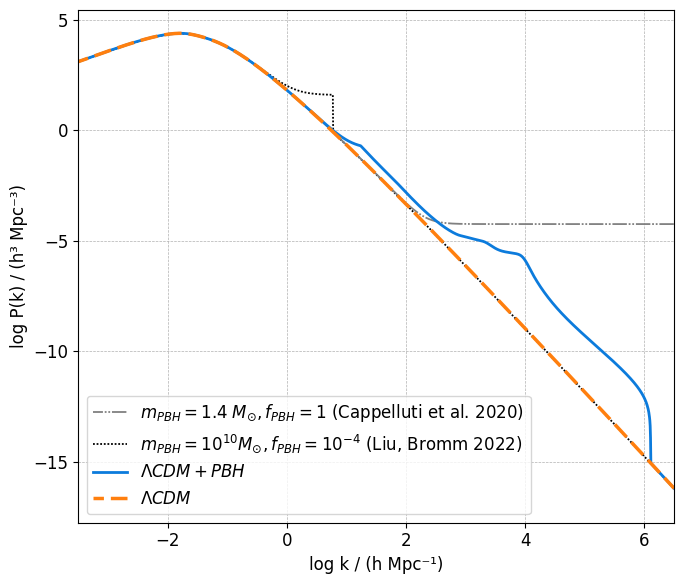

In [6]:
# ─── Plot in h-units ─────────────────────────────────────────────────────────
k_h      = k_vals / h
P_l_h    = P_lcdm    * h**3
P_pbh_h  = P_pbh     * h**3
P_tot_h  = P_tot_norm * h**3
P_tot_h1  = P_tot_norm1 * h**3
P_tot_h2  = P_tot_norm2 * h**3
P_tot_h3  = P_tot_norm3 * h**3
P_tot_h4  = P_tot_norm4 * h**3

plt.figure(figsize=(7,6))
plt.rcParams.update({'font.size': 12})
#plt.plot(np.log10(k_h), np.log10(P_tot_h1), label=r'$m_{PBH}=3$ $\times$ $10^{5}$ $M_{\odot}$, $f_{PBH}$ = 3 $\times$ $10^{-4}$ (Liu, Bromm 2022)',linewidth=1.3,c='k',linestyle='-.')
plt.plot(np.log10(k_h), np.log10(P_tot_h2), label=r'$m_{PBH}= 10^{10} M_{\odot}, f_{PBH} = 10^{-4}$ (Liu, Bromm 2022)',linewidth=1.3,c='k',linestyle=(0,(1,1)))
plt.plot(np.log10(k_h), np.log10(P_tot_h3), label=r'$m_{PBH}=1.4 \;M_{\odot}, f_{PBH} = 1$ (Cappelluti et al. 2020)',linewidth=1.3,c='gray',linestyle=(2.5, (8, 1, 1, 1, 1, 1)))
#plt.plot(np.log10(k_h), np.log10(P_tot_h4), label=r'$m_{PBH}= 30 \;M_{\odot}, f_{PBH} = 1$ (Kashlinsky et al. 2018)',linewidth=1.5,c='gray',linestyle=(3.5, (8, 1, 1, 1, 1, 1, 1, 1, 1, 1,1,1))) #(0,(1,3))
plt.plot(np.log10(k_h), np.log10(P_tot_h), label=r'$\Lambda CDM + PBH$',linewidth=2,c='#0C7BDC')
plt.plot(np.log10(k_h), np.log10(P_l_h), label=r'$\Lambda CDM$',linewidth=2.5,c='C1',linestyle=(2,(5,2)))

handles,labels = plt.gca().get_legend_handles_labels()
order = [3,2,1,0,4,5]
order = [1,0,2,3]


plt.xlim(-3.5,6.5)
plt.xlabel('log k / (h Mpc⁻¹)')
plt.ylabel('log P(k) / (h³ Mpc⁻³)')
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],loc='lower left')
plt.grid(True, which='both', ls='--', lw=0.5)
plt.tight_layout()
plt.savefig("figurepaper/PS.png", dpi=1000, bbox_inches='tight')
plt.show()

## Star Formation Rate Density

In [ ]:
# Implement the full pipeline connecting PBH-modified cosmological structure formation
# to observable star formation: starting from the total matter power spectrum (including
# PBH contributions), compute the mass variance σ(M, z), derive the halo mass function
# dn/dM using a Tinker-like prescription, evaluate halo mass accretion rates following
# Behroozi & Silk (2015), and integrate over halo mass with model-dependent star formation
# efficiencies to obtain the cosmic star formation rate density.

# ── background cosmology (H(z), dz/dt) ──────────────────────────────────────
def H_z(z, h=h, Om=Om, Ov=Ov):
    """
    H(z) in SI units [s^-1] for a flat background with (Om, Ov).
    """
    H0_SI = 100.0 * h * KM / MPC
    Ez = np.sqrt(Om * (1.0 + z) ** 3 + Ov)
    return H0_SI * Ez

def dz_dt(z, h=h, Om=Om, Ov=Ov):
    """
    dz/dt in [s^-1] at redshift z.
    Uses dz/dt = - (1+z) H(z).
    """
    return - (1.0 + z) * H_z(z, h=h, Om=Om, Ov=Ov)

# ── Behroozi & Silk (2015) Appendix B: M_med pieces ─────────────────────────
def M13(z):
    """
    Eq. (B2): M13(z) [Msun].
    """
    return (10.0 ** 13.276) * (1.0 + z) ** 3.00 * (1.0 + z / 2.0) ** (-6.11) * np.exp(-0.503 * z)

def a0_of_M0(M0):
    """
    Eq. (B5): a0(M0).
    """
    return 0.205 - np.log10(((10.0 ** 9.649) / M0) ** 0.18 + 1.0)

def g_of_M0_a(M0, a):
    """
    Eq. (B4): g(M0, a).
    """
    return 1.0 + np.exp(-4.651 * (a - a0_of_M0(M0)))

def f_of_M0_z(M0, z):
    """
    Eq. (B3): f(M0, z) with a = 1/(1+z).
    """
    a = 1.0 / (1.0 + z)
    return np.log10(M0 / M13(0.0)) * (g_of_M0_a(M0, 1.0) / g_of_M0_a(M0, a))

def M_med(M0, z):
    """
    Eq. (B1): M_med(M0, z) [Msun].
    """
    return M13(z) * (10.0 ** f_of_M0_z(M0, z))


def g_of_logM0_a(log10M0, a):
    M0 = 10.0**log10M0
    return 1.0 + np.exp(-4.651 * (a - a0_of_M0(M0)))

def make_log10_Mmed_from_log10M0(log10_M13_0, M13_of_z, g_of_logM0_a):
    """
    Return a callable f(log10M0, z) = log10 M_med(M0, z), using Behroozi-Silk Appendix B:
      log10 M_med = log10 M13(z) + (log10M0 - log10 M13(0)) * [ g(logM0, a=1) / g(logM0, a) ].
    All pieces are evaluated in log-space to avoid overflow.
    """
    def log10_Mmed(log10M0, z):
        a = 1.0 / (1.0 + z)
        g_ratio = g_of_logM0_a(log10M0, 1.0) / g_of_logM0_a(log10M0, a)
        return np.log10(M13_of_z(z)) + (log10M0 - log10_M13_0) * g_ratio
    return log10_Mmed


def invert_M0_for_Mpeak(Mpeak, z, log10_Mmed_from_log10M0):
    """
    Solve for M0 such that log10_Mmed_from_log10M0(log10 M0, z) = log10 Mpeak.
    Uses robust log-space bracketing + bisection. No asymptotic guesses needed.
    """
    Mpeak = float(Mpeak)
    if z <= 1e-12:
        return Mpeak  # M_med(M0,0) = M0

    v = np.log10(Mpeak)

    # Define monotone residual F(u) = log10 M_med(10^u, z) - v
    def F(u):
        return log10_Mmed_from_log10M0(u, z) - v

    # Start lower bound at u = log10 Mpeak (guarantees F(u_lo) < 0 for z>0)
    u_lo = v
    F_lo = F(u_lo)
    if F_lo >= 0.0:
        # Only possible if z~0 numerically; fall back to identity
        return Mpeak

    # Grow an upper bound until we flip sign (monotone => guaranteed)
    u_hi = u_lo + 3.0
    F_hi = F(u_hi)
    it = 0
    while F_hi <= 0.0 and it < 128:
        u_hi += 1.0     # +1 dex per step
        F_hi = F(u_hi)
        it += 1
    if F_hi <= 0.0:
        raise RuntimeError(
            f"Failed to bracket M0 up to log10(M0)={u_hi:.2f} for Mpeak={Mpeak:.3e}, z={z:g}"
        )

    for _ in range(64):
        u_mid = 0.5 * (u_lo + u_hi)
        F_mid = F(u_mid)
        if abs(F_mid) < 1e-12:
            return 10.0**u_mid
        if F_mid > 0.0:
            u_hi = u_mid
        else:
            u_lo = u_mid
    return 10.0**(0.5 * (u_lo + u_hi))



# ── dM_med/dt via finite differencing in z at fixed M0 ───────────────────────
def dMmed_dt(Mpeak, z, dz=1e-3, h=h, Om=Om, Ov=Ov):
    """
    Time derivative (d/dt) M_med at the (M0, z) implied by the inversion above.
    Central difference in z when z>dz; forward difference near z=0.
    Returns Msun / s.
    """
    M0 = invert_M0_for_Mpeak(Mpeak, z,log10_Mmed)

    if z <= dz:
        z1, z2 = z, z + dz
    else:
        z1, z2 = z - dz, z + dz

    dM_dz = (M_med(M0, z2) - M_med(M0, z1)) / (z2 - z1)
    return dM_dz * dz_dt(z, h=h, Om=Om, Ov=Ov)


# ── Behroozi & Silk (2015) Eq. (B8): multiplicative correction F ─────────────
def F_correction(Mpeak, a):
    """
    Factors in Eq. (B8):
      [0.22 (a - 0.4)^2 + 0.85]
      (Mpeak / 1e12)^(0.05 a)
      (1 + 10^(11 - 0.5 a) * Msun / Mpeak)^(0.04 + 0.1 a)
    """
    term1 = 0.22 * (a - 0.4) ** 2 + 0.85
    term2 = (Mpeak / 1.0e12) ** (0.05 * a)
    term3 = (1.0 + (10.0 ** (11.0 - 0.5 * a)) / Mpeak) ** (0.04 + 0.1 * a)
    return term1 * term2 / term3

# Compute the average halo mass accretion rate <Mdot_h>(M, z) following the
# Behroozi & Silk (2015) formalism, combining the median mass growth history
# with empirical correction factors to obtain the mean accretion rate in Msun/yr.

# ── Mdot_h(M, z) ─────────────────────────────────────────────────
def Mdot_h_behroozi(M_vals, z_vals, dz=1e-3, h=h, Om=Om, Ov=Ov):
    """
    Average halo accretion rate <Mdot_peak>(M, z) == Mdot_h(M, z) for distinct halos.
    Output units: Msun / yr.
    """
    SEC_PER_YR = 365.25 * 24 * 3600.0
    M_vals = np.atleast_1d(M_vals).astype(float)
    z_vals = np.atleast_1d(z_vals).astype(float)
    out = np.empty((M_vals.size, z_vals.size), dtype=float)

    for i, M in enumerate(M_vals):
        for j, z in enumerate(z_vals):
            mdot_med_sec = dMmed_dt(M, z, dz=dz, h=h, Om=Om, Ov=Ov)  # Msun / s
            a = 1.0 / (1.0 + z)
            mdot_peak_sec = mdot_med_sec * F_correction(M, a)         # Msun / s
            out[i, j] = mdot_peak_sec * SEC_PER_YR                    # Msun / yr
    return out

LOG10_M13_0 = 13.276  # = log10 M13(0)
log10_Mmed = make_log10_Mmed_from_log10M0(LOG10_M13_0, M13, g_of_logM0_a)


# Compute the mass variance σ(M, z) sourced by the total matter power spectrum,
# including PBH contributions, by filtering P(k) with a spherical top-hat window
# and evolving it with the linear growth factor.
def sigma_PBH_z(M_grid, z_vals, k, P_tot, Om, rho_cr):

    Nm = len(M_grid)
    Nz = len(z_vals)
    var0_PBH = np.zeros(Nm)

    for i, M in enumerate(M_grid):
        R = (3*M / (4 * np.pi * Om * rho_cr))**(1/3)
        x = k * R
        W = 3 * (np.sin(x) - x * np.cos(x)) / x**3
        integrand = P_tot * W**2 * k**2
        var0_PBH[i] = simpson(integrand, x=k) / (2*np.pi**2)

    sigma_pbh_z = np.zeros((Nm, Nz))
    for iz, z in enumerate(z_vals):
        D = growth(z)  # linear growth factor
        sigma_pbh_z[:, iz] = np.sqrt(var0_PBH) * D

    return sigma_pbh_z

# Evaluate the halo mass function dn/dM(M, z) using the Tinker et al. (2008)
# prescription, where the variance σ(M, z) is derived from the total (ΛCDM + PBH)
# power spectrum, and the multiplicity function is calibrated to simulations.
def mass_func(M, z,k_vals,P_tot,Om,rho_cr):
    #Tinker 2008
    Nm = len(M)
    Nz = len(z)
    
    sigmaM = sigma_PBH_z(M,z,k_vals,P_tot,Om,rho_cr)
       
    lognu = np.log(1.0 / sigmaM)   # shape (Nm, Nz)
    dlnnu_dM = np.zeros_like(lognu)

    for iz in range(Nz):
        # gradient of lognu[:, iz] w.r.t. M
        dlnnu_dM[:, iz] = np.gradient(lognu[:, iz], M)

    rho_m0 = 3 * (h * 100.0)**2 / (3.085e19)**2 / (8 * np.pi * 6.67e-8) * Om
    rho_m = rho_m0 * (3.085e24)**3 / 2e33  # in Msun/Mpc3

    dndM = np.zeros((Nm, Nz))
    for zz in range(Nz):

        logalpha = -(0.75 / np.log10(200.0 / 75))**1.2
        alpha = 10**logalpha
        Aa = 0.186 * (1 + z[zz])**(-0.14)
        a = 1.47 * (1 + z[zz])**(-0.06)
        b = 2.57 * (1 + z[zz])**(-alpha)
        c = 1.19

        f = Aa * (1 + (sigmaM[:, zz]  / b )**(-a)) * np.exp(-c / sigmaM[:, zz]**2)
        dndM[:, zz] = f * rho_m * dlnnu_dM[:, zz] / M
    return dndM

# Compute the cosmic star formation rate density by integrating over the halo
# population, combining the PBH-modified halo mass function, halo accretion rates,
# and model-dependent star formation efficiencies (Harikane, Furlanetto, or
# Sipple & Lidz), with optional treatment of Population III contributions (not implemented).
def mk1pop_pbh(zr,k_vals,P_tot,Om,rho_cr,param,pop3=False):

    # Mass grid and star-formation efficiency η(M)
    Nm = 100
    M = 10 ** np.linspace(6, 18, Nm)

    # Base PBH‐halo mass function
    dndM_tinker = mass_func(M, zr,k_vals,P_tot,Om,rho_cr)


    #correction factors in Behroozi et al. 2013
    fact1 = 0.144 / (1 + np.exp(14.79 * (1 / (1+zr[None,:]) - 0.213)))
    fact2 = (M[:,None] / 10**11.5)**(0.5/(1 + np.exp(6.5 * (1 / (1+zr[None,:])))))
    
    dndM = dndM_tinker * 10**(fact1 * fact2)

    if param == 'Harikane':
    # Star formation efficiency by Harikane 2022

        #Behroozi 2015 accretion rate
        M_dot_h = Mdot_h_behroozi(M,zr, dz=1e-3, h=h, Om=Om, Ov=Ov)

        #SFE
        f0, mp = 2*3.2*1e-2, 10**11.5
        glow, ghi = -1.2,0.5
        sfe_mass = f0 / ((M/mp)**glow + (M/mp)**ghi) 
        sfe_harik = sfe_mass[:, None]
        sfe2d = sfe_harik*(0.53*np.tanh(0.54*(2.9-zr))+1.53)
    
    elif param == 'Furlanetto':
    # Star formation efficiency by Furlanetto 2016

        #Sun, Furlanetto 2016 accretion rate
        M_dot_acc = 3. * (M[:,None]/1e10)**1.127 * ((1. + zr) / 7.)[None,:]**2.5 
        M_dot_h = M_dot_acc / (Ob / Om)

        #SFE
        f0, mp =0.05, 2.8e11
        glow, ghi = 0.49, -0.61
        f_min = 0.000
        sfe_mass = f0 / ((M/mp)**glow + (M/mp)**ghi) + f_min
        sfe_furl = sfe_mass[:, None]
        sfe2d = sfe_furl.dot(np.ones((1,len(zr))))    #(constant in z)
    
    else:
    # Star formation efficiency by Sipple & Lidz 2022

        #Sun, Furlanetto 2016 accretion rate
        M_dot_acc = 3. * (M[:,None]/1e10)**1.127 * ((1. + zr) / 7.)[None,:]**2.5 
        M_dot_h = M_dot_acc / (Ob / Om)

        #SFE
        sigma = 0.37
        delta = 1.127
        eta = 2.5
        p, q, r1, M_uv0, log10M1 = param
        r2 = r1
        M1 =  10**log10M1
        g_fact = 0.5 * (sigma**2 - 0.37**2) + 2/5 * np.log(10) * (-23.79 - M_uv0)
        sfe_fact = 0.2 * np.exp(g_fact) * ( (2 * (M / M1)**(p - delta)) / (1 + (M / M1)**q) ) 
        sfe_mass2 = sfe_fact[:,None]
     
        zd = np.zeros(len(zr))
        for iz, zval in enumerate(zr):
            if zval <= 10:
                zd[iz] = ((1 + zval)/7)**(r1 - eta)
            else:
                zd[iz] = ((1 + zval)/7)**(r2 - eta)
        sfe_z = zd[None, :]    
        sfe2d = sfe_mass2 * sfe_z * (Ob / Om)
    
        
    sfr = np.zeros(len(zr))

    if pop3 == False:
        pass
        
    dlnM = np.log(M[1]/M[0])
    integrand =  M_dot_h * sfe2d * M[:,None] * dndM 
    sfr = dlnM * np.sum(integrand,axis=0) 
    
    return sfr

#### Figure

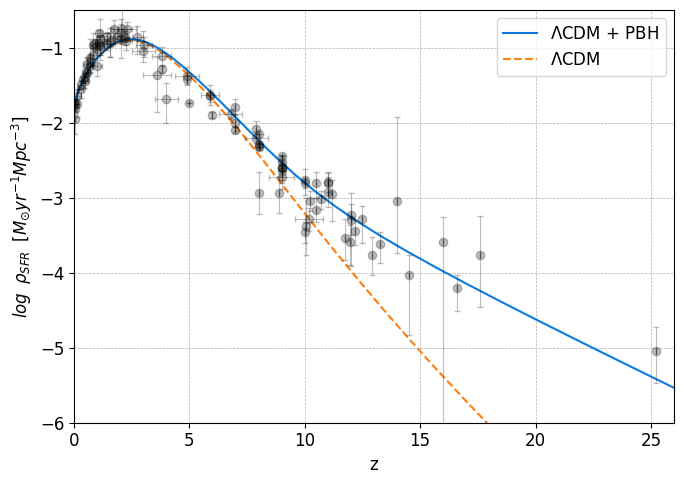

In [ ]:
# Load the observed star formation rate density compilation, extract the measurements and
# their asymmetric uncertainties, evaluate the predicted cosmic star formation history over
# a redshift grid for both the fiducial ΛCDM case and the PBH-augmented model using the
# adopted star-formation prescription, and compare the two predictions against the data.

df = pd.read_csv("SFRs.csv", comment="#")
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

z_sfr = df["z_best"].to_numpy()
y_sfr = df["log_SFR"].to_numpy()

xerr_plus  = df["z_err_plus"]
xerr_minus = df["z_err_minus"]
yerr_plus  = df["log_SFR_err_plus"]
yerr_minus = df["log_SFR_err_minus"]


nz = 100     
zmin = 0.01
zmax = 30.0
    
# Redshift
z = np.logspace(np.log10(zmin), np.log10(zmax), nz)


# mk1pop_pbh functions
# LCDM + PBH
sfr_pbh_B = mk1pop_pbh(z,
                 k_vals=k_vals, P_tot=P_tot, Om=Om, rho_cr=rho_cr,param='Harikane')

# only LCDM
sfr_lcdm_B = mk1pop_pbh(z,
                 k_vals=k_vals, P_tot=P_lcdm, Om=Om, rho_cr=rho_cr,param='Harikane')


# Plot data points with asymmetric x/y errors
plt.figure(figsize=(7,5))


#plt.plot(z,np.log10(sfr_lcdm_B),c='#FFC20A',linestyle='--',label=r'$\Lambda$CDM') 
plt.plot(z,np.log10(sfr_lcdm_B),c='C1',linestyle='--',label=r'$\Lambda$CDM') 
plt.plot(z,np.log10(sfr_pbh_B),c='#0C7BDC',label=r'$\Lambda$CDM + PBH') 

plt.errorbar(
    z_sfr, y_sfr,
    xerr=np.vstack([xerr_minus, xerr_plus]),
    yerr=np.vstack([yerr_minus, yerr_plus]),
    fmt='o', color='black', capsize=2,elinewidth=0.8,alpha=0.25
)

handles,labels = plt.gca().get_legend_handles_labels()
order = [1,0]

plt.xlabel('z', fontsize=12)
plt.ylabel(r'$log\;\; \rho_{SFR} \;\;[M_{\odot} yr^{-1} Mpc^{-3}]$', fontsize=12)
plt.grid(True, ls='--', lw=0.5)
plt.ylim([-6,-0.5])
plt.xlim([0,26])
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order])
plt.tight_layout()
plt.savefig("figurepaper/SFRD.png", dpi=100, bbox_inches='tight')

plt.show()

## Thomson Optical Depth

In [ ]:
# Compute the ionization history and Thomson optical depth implied by the model by
# converting the predicted cosmic star formation rate density into an ionizing-photon
# production rate, evolving the volume-averaged ionized fraction with recombinations,
# and integrating the resulting free-electron density along the line of sight.

def tau(zr, PS, param,f_esc):
    # z grid
    zall   = zr
    Hz     = H0 * np.sqrt(Om*(1+zall)**3 + Ov)
    dtdz   = 1.0 / ((1+zall)*Hz)         # s per unit z

    # PBH‑driven SFR
    rho_sfr = mk1pop_pbh(zr, k_vals, PS, Om, rho_cr, param) # M⊙ yr⁻¹ Mpc^-3
    
    
    # photons / cm³ /s
    xi_ion = 10**53.35      # photons s⁻¹ M⊙⁻¹ yr 
    n_ion  = f_esc * xi_ion * rho_sfr / Mpc2cm**3 # photons s⁻¹ cm^-3
 
    # recombination coefficient at T=2×10⁴K
    clumping = 3.0
    T_rec    = 2     # 1e4 K
      
    #Shull 2012
    alpha_B = 2.59 *10**-13 * T_rec**-0.845

    # comoving H density at z=0 [cm⁻³]
    rho_c   = 3*H0**2/(8*np.pi*6.67e-8) # g cm^-3 
    X, Y    = 0.7547, 0.2453
    m_H = 1.6726e-24 # g
    n_H0    = Ob * rho_c * X / m_H # cm^-3


    # x_ion
    x_ion = np.zeros_like(zall)

    for i in range(len(zall)-2, -1, -1):
        zL, zR = zall[i], zall[i+1]
        dz     = zR - zL
        # midpoint time step for accuracy
        dt     = 0.5*(dtdz[i] + dtdz[i+1]) * dz

        # Midpoint redshift for evaluating varying quantities
        zm     = 0.5*(zL + zR)

        # Source term per H atom [s^-1] at midpoint
        # (rho_sfr is comoving; n_H0 is comoving)
        source = (0.5*(n_ion[i] + n_ion[i+1])) / n_H0

        # Recombination time [s] using consistent He factor and PROPER density at midpoint
        n_Hp_m = n_H0 * (1.0 + zm)**3  # proper hydrogen density
        
        e_m = 1.0 + Y/(4*X)
        
        trec   = 1.0 / (clumping * alpha_B * n_Hp_m * e_m)

        # Backward-Euler update for x:
        # x_i = (x_{i+1} + source*dt) / (1 + dt/trec)
        x_new  = (x_ion[i+1] + source*dt) / (1.0 + dt/trec)

        # Safety clip (rarely needed with backward-Euler)
        x_ion[i] = np.clip(x_new, 0.0, 1.0)
    
    def he_mult(z): 
        # 1 + chi_He(z): 1 + Y/(4X) for He II; 1 + 2Y/(4X) for He III (z <= 3)
        return 1.0 + ((Y/(4*X)) * (2.0 if z <= 3.0 else 1.0))

    # electron density for τ integral
    n_e = x_ion * (n_H0 * (1.0 + zall)**3) * np.array([he_mult(z) for z in zall])

    #dtdz   = 1.0 / ((1+zall)*Hz) 

    # compute τ(z)
    integrand = c_cgs * sigma_T * n_e * dtdz 

    tau_z = cumulative_trapezoid(integrand,zall,initial=0.0)

    return {'z_ion': zall, 'x_ion': x_ion, 'tau_z': tau_z,'f_esc':f_esc}

#### Figure

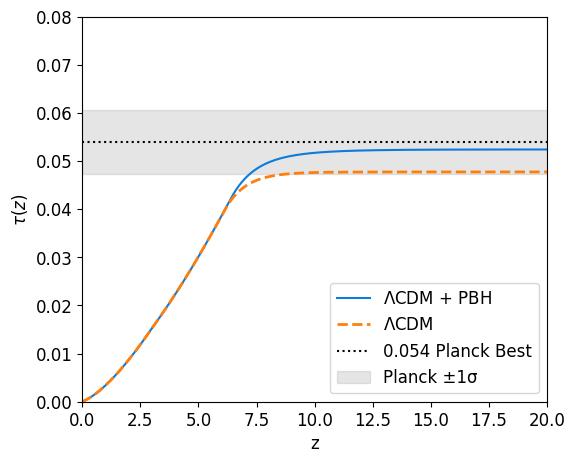

In [ ]:
# Evaluate and compare the cumulative Thomson optical depth τ(z) for the PBH-augmented
# and ΛCDM scenarios, using the previously computed ionization histories, and contrast
# the predictions with the Planck constraint including its 1σ uncertainty band.

zr  = np.linspace(0, 20, 500)
f_esc = 0.3

res3 = tau(zr, P_tot, "Harikane",f_esc)
res4 = tau(zr, P_lcdm, "Harikane",f_esc)

plt.figure(figsize=(6, 5))

plt.plot(res3['z_ion'], res3['tau_z'], c='#0C7BDC',label=r'$\Lambda$CDM + PBH',linewidth=1.5) 
plt.plot(res4['z_ion'], res4['tau_z'], c='C1',linestyle='--',label=r'$\Lambda$CDM',linewidth=2) 


plt.axhline(y=0.054, color='black',label='0.054 Planck Best',linestyle='dotted')
plt.fill_between(res3['z_ion'], 0.054-0.0066, 0.054+0.0066,
                 alpha=0.2, label='Planck ±1σ',color='gray')


plt.xlabel('z')
plt.ylabel(r'$\tau(z)$')
plt.xlim(0, 20)
plt.ylim(0.0, 0.08)
plt.legend()
plt.savefig("figurepaper/opticaldepth.png", dpi=100, bbox_inches='tight')
plt.show()

## Reionization History

#### Figure

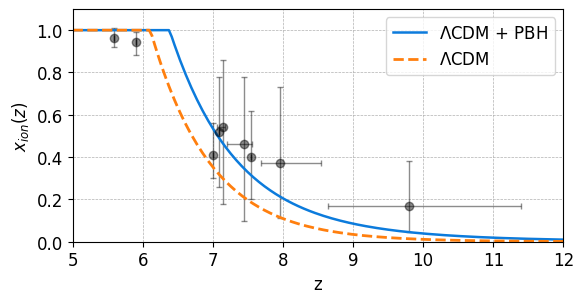

In [ ]:
# Load observational constraints on the ionized fraction, convert reported uncertainties
# into asymmetric errors, and compare these data to the predicted reionization histories
# x_ion(z) for both the ΛCDM and PBH-augmented scenarios.

df = pd.read_csv("xi_values.csv")
df.columns = [c.strip().lower() for c in df.columns]

# Required columns
cols = ["z_best","xi_best","xi_err_plus","xi_err_minus"]
for c in cols: 
    if c not in df: 
        raise ValueError(f"Missing column: {c}")

# Optional x error endpoints (interpret as END VALUES, not deltas)
df["z_err_plus"]  = pd.to_numeric(df.get("z_err_plus", 0), errors="coerce").fillna(0)
df["z_err_minus"] = pd.to_numeric(df.get("z_err_minus",0), errors="coerce").fillna(0)

# Convert END VALUES -> DELTAS (clip to >=0). 0 means no x error.
z  = pd.to_numeric(df["z_best"], errors="coerce")
y  = pd.to_numeric(df["xi_best"], errors="coerce")
yep = np.clip(pd.to_numeric(df["xi_err_plus"], errors="coerce")  - y, 0, None)
yem = np.clip(y - pd.to_numeric(df["xi_err_minus"], errors="coerce"), 0, None)
xep = np.clip(df["z_err_plus"]  - z, 0, None)
xem = np.clip(z - df["z_err_minus"], 0, None)

# Plot
plt.figure(figsize=(6.0, 3.2))

plt.errorbar(
    z, y, 
    xerr=np.vstack([xem, xep]), 
    yerr=np.vstack([yem, yep]), 
    fmt='o', color='black', capsize=2,elinewidth=1,alpha=0.45)


plt.plot(res3['z_ion'], res3['x_ion'], c='#0C7BDC',label=r'$\Lambda$CDM + PBH',linewidth=1.8) 
plt.plot(res4['z_ion'], res4['x_ion'], c='C1',linestyle='--',label=r'$\Lambda$CDM',linewidth=2) 
plt.grid(True, ls='--', lw=0.5)
plt.xlim(5,12)
plt.ylim(0, 1.1)
plt.xlabel('z')
plt.ylabel(r'$x_{ion}(z)$')
plt.legend()
plt.tight_layout()
plt.savefig("figurepaper/reionizationhistory.png", dpi=100, bbox_inches='tight')

plt.show()


## LVK Detectable event rate

In [ ]:
# Implement the full pipeline to compute PBH binary merger and detection rates
# for an extended mass function: starting from a tabulated df_PBH/dlnM, construct
# the normalized PBH mass distribution and corresponding number densities, model
# gravitational-wave capture and intrinsic merger rates, and combine these with
# detector sensitivity (via noise curves and SNR integrals) to estimate the
# observable merger rate as a function of binary component masses.


# ============================================================
# PBH PARAMETERS
# ============================================================

delta_loc = 3e5
v         = np.sqrt(2)*2.5e7         # cm/s
fPBH      = 0.339         # target total PBH fraction

# ============================================================
# PBH MASS FUNCTION: df_PBH/dlnM (M in Msun)
# ============================================================

file_path = 'FA2.txt'
mass_smooth_factor = 0.1

with open(file_path, 'r') as f:
    lines = f.read().splitlines()

for line in lines:
    if line.lstrip().startswith('x'):
        x = ast.literal_eval(line.split('=', 1)[1])
    elif line.lstrip().startswith('y'):
        y = ast.literal_eval(line.split('=', 1)[1])

x = np.array(x, float)
y = np.array(y, float)
mask = (x > 0) & (y > 0)
x_pos, y_pos = x[mask], y[mask]   # masses in Msun

spline_log = UnivariateSpline(np.log10(x_pos),
                              np.log10(y_pos),
                              s=mass_smooth_factor)

def df_pbh_dlnM_raw(M):
    """Raw df_PBH/dlnM from FA2.txt (not yet normalized to fPBH)."""
    return 10.0**spline_log(np.log10(M))

# normalize to the desired total fPBH
M_min, M_max = x_pos.min(), x_pos.max()
M_grid_norm = np.logspace(np.log10(M_min), np.log10(M_max), 2000)
df_raw_grid = df_pbh_dlnM_raw(M_grid_norm)
fPBH_raw = simpson(df_raw_grid / M_grid_norm, x=M_grid_norm)   # ∫ df dlnM
scale = fPBH / fPBH_raw

def df_pbh_dlnM(M):
    """df_PBH/dlnM normalized so that ∫ df_PBH dlnM = fPBH."""
    return scale * df_pbh_dlnM_raw(M)

# effective ΔlnM from the tabulated mass grid
lnM_tab = np.log(x_pos)
dlnM_eff = np.median(np.diff(lnM_tab))


def n_bin(M):
    """
    Number density in a logarithmic mass bin around M (Msun):
    n(M) ≈ (dn/dlnM) ΔlnM
    with dn/dlnM = (rhoDM * delta_loc / (M*Msun)) * df_PBH/dlnM(M).
    """
    M_cgs = M * Msun
    dn_dlnM = (rhoDM * delta_loc / M_cgs) * df_pbh_dlnM(M) * np.log(10) 
    return dn_dlnM * dlnM_eff        # cm^-3

# ============================================================
# GW SETTINGS
# ============================================================

fmin = 10.0
fmax = 2000.0

# ============================================================
# BUILD NOISE SPLINE (ASD)
# ============================================================

def build_noise_spline(noise_filepath, s=1):
    data = np.loadtxt(noise_filepath)
    f, asd = data[:,0], data[:,1]
    mask = (f > 0) & (asd > 0)
    f, asd = f[mask], asd[mask]
    idx = np.argsort(f)
    return UnivariateSpline(np.log10(f[idx]), np.log10(asd[idx]), s=s)

noise_spline = build_noise_spline("O3-H1.txt", s=1)

# ============================================================
# BUILD TWO INTEGRAL TABLES
# ============================================================

def build_integral_table(noise_spline, fmin, fmax, alpha, n=200000):
    f = np.linspace(fmin, fmax, n)
    asd = 10**noise_spline(np.log10(f))
    Sh  = np.clip(asd**2, np.finfo(float).tiny, None)
    integrand = f**(-alpha) / Sh
    df = np.diff(f)
    cum = np.concatenate(([0], np.cumsum(0.5*(integrand[:-1] + integrand[1:])*df)))
    return f, cum

# inspiral    α = 7/3
f1_grid, cum1 = build_integral_table(noise_spline, fmin, fmax, alpha=7/3)
# post-inspiral α = 2/3
f2_grid, cum2 = build_integral_table(noise_spline, fmin, fmax, alpha=2/3)

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def chirp_mass(mA, mB):
    M = mA + mB
    return (mA*mB)**(3/5) / (M**(1/5))

def freqs(mA, mB):
    """
    Return (f_ISCO, f_merg) in Hz.

    - f_ISCO is kept as your usual 4400 / Mtot (with Mtot in Msun).
    - f_merg uses the Ajith et al. IMR phenomenological fit:

        π M f_merg = a0 η^2 + b0 η + c0

      where M is the total mass in geometric units (seconds) and
      η is the symmetric mass ratio.
    """
    mA   = float(mA)
    mB   = float(mB)
    Mtot = mA + mB
    eta  = (mA * mB) / (Mtot**2)

    # Ajith et al. (non-spinning) coefficients, 
    a0 = 6.6389e-1
    b0 = -1.0321e-1
    c0 = 1.0979e-1

    # total mass in geometric units (seconds)
    M_geom = G_cgs * (Mtot * Msun) / c_cgs**3

    # ISCO frequency (same approximation you used before), in Hz
    fISCO = 4400.0 / Mtot

    # merger frequency from Ajith fit, in Hz
    fMERGE = (a0 * eta**2 + b0 * eta + c0) / (pi * M_geom)
    # fMERGE = 8 * fISCO * eta
    # cap at the detector's high-frequency cutoff
    fMERGE = min(fMERGE, fmax)

    return fISCO, fMERGE

def R_det(mA, mB):

    # chirp mass in grams
    Mc = chirp_mass(mA, mB) * Msun

    # geometric chirp mass (seconds)
    Mc_geom = G_cgs * Mc / c_cgs**3

    # frequencies
    fISCO, fMAX = freqs(mA, mB)
    # enforce band [fmin, fmax] for the lower limit
    fISCO_eff = np.minimum(np.maximum(fISCO, fmin), fmax)

    # integrals
    I1 = np.interp(fISCO_eff, f1_grid, cum1)
    I2 = (np.interp(fMAX, f2_grid, cum2)
          - np.interp(fISCO_eff, f2_grid, cum2))

    Itot = max(I1 + I2, 0.0)

    # geometric-units prefactor
    pref_geom = (np.sqrt(5.0) / 24.0) * (Mc_geom**(5.0/6.0)) / (pi**(2.0/3.0) * 2.26)

    # convert seconds -> cm
    R_cm = pref_geom * np.sqrt(Itot) * c_cgs

    return R_cm

# ============================================================
# INTRINSIC MERGER RATE τ_L(mA,mB) WITH EXTENDED MASS FUNCTION
# ============================================================

def tau_L(mA, mB):
    """
    Intrinsic merger rate per volume (s^-1 cm^-3) for a pair with
    component masses mA, mB (in Msun), using the extended PBH mass
    function:
        τ_L = n(mA) n(mB) σ(mA,mB,v) v
    """
    # number densities for bins around mA, mB
    nA = n_bin(mA)     # cm^-3
    nB = n_bin(mB)     # cm^-3

    # masses in grams
    mA_cgs = mA * Msun
    mB_cgs = mB * Msun
    M_cgs  = mA_cgs + mB_cgs

    # capture cross section σ̄(mA,mB,v)
    pref = 2.0 * pi * ((85.0 * pi) / (6.0 * np.sqrt(2.0)))**(2.0/7.0)
    sigma = (pref * G_cgs**2 *
             M_cgs**(10.0/7.0) * (mA_cgs*mB_cgs)**(2.0/7.0) *
             c_cgs**(-10.0/7.0) * v**(-18.0/7.0))   # cm^2

    # intrinsic rate density
    return nA * nB * sigma * v    # s^-1 cm^-3

# ============================================================
# FINAL FUNCTION: DETECTED MERGER RATE IN yr^-1
# ============================================================

def detected_rate(mA, mB):
    Rcm = R_det(mA, mB)     # cm
    tau = tau_L(mA, mB)     # s^-1 cm^-3
    #print((4*np.pi/3.0) * Rcm**3)
    rate_s = tau * (4*np.pi/3.0) * Rcm**3   # s^-1
    return rate_s * SEC_PER_YR  # yr^-1


In [ ]:
# Construct a two-dimensional grid of binary component masses, compute the
# predicted PBH detection rate over the physically allowed parameter space,
# and map it in log-space, then load gravitational-wave events, extract their
# masses and uncertainties, and clean the catalog by removing nearly-duplicate
# entries for a consistent comparison with the model predictions.

def chirp_mass(M1, M2):
    """Chirp mass in solar masses."""
    M1 = np.asarray(M1, dtype=float)
    M2 = np.asarray(M2, dtype=float)
    return (M1 * M2)**(3.0/5.0) / (M1 + M2)**(1.0/5.0)

# -------------------------------------------------
# Mass ranges and grid (M1 >= M2 enforced)
# -------------------------------------------------
M1_min, M1_max = 1.0, 250.0   # Msun
M2_min, M2_max = 1.0, 250.0   # Msun

n_M1, n_M2 = 300, 300

logM1_vals = np.linspace(np.log10(M1_min), np.log10(M1_max), n_M1)
logM2_vals = np.linspace(np.log10(M2_min), np.log10(M2_max), n_M2)

M1_vals = 10**logM1_vals
M2_vals = 10**logM2_vals

M1_grid, M2_grid = np.meshgrid(M1_vals, M2_vals, indexing='xy')

# Enforce M1 >= M2 (half the area blank)
diag_mask = (M1_grid >= M2_grid)

# -------------------------------------------------
# Allowed region from q and Mc cuts
# -------------------------------------------------
q = np.minimum(M1_grid, M2_grid) / np.maximum(M1_grid, M2_grid)
Mc_grid = chirp_mass(M1_grid, M2_grid)

Mc_low, Mc_high = 0.1, 190.0  # Msun

mask = (
    diag_mask &
    (q >= 0.005) & (q <= 1.0) &
    (Mc_grid >= Mc_low) & (Mc_grid <= Mc_high)
)

# -------------------------------------------------
# Detected rate on the grid (only in allowed region)
# -------------------------------------------------
rate_grid = np.full_like(M1_grid, np.nan, dtype=float)

# loop over grid; this is ~3.6e5 points
for i in range(M1_grid.shape[0]):
    for j in range(M1_grid.shape[1]):
        if mask[i, j]:
            rate_grid[i, j] = detected_rate(M1_grid[i, j], M2_grid[i, j])

# -------------------------------------------------
# Take log10, treating zeros as a fixed floor
# -------------------------------------------------
log_rate = np.full_like(rate_grid, np.nan, dtype=float)

# valid points inside the physical mask
valid_mask = mask & np.isfinite(rate_grid)

# positive rates
pos = valid_mask & (rate_grid > 0.0)

if np.any(pos):
    # log of positive rates
    log_rate[pos] = np.log10(rate_grid[pos])

    # choose a floor one dex below the minimum positive value
    log_min_pos = np.nanmin(log_rate[pos])
    log_floor = log_min_pos - 1.0   # adjust if you want a different floor

    # cells with exactly zero rate but inside allowed region
    zero_mask = valid_mask & (rate_grid == 0.0)
    log_rate[zero_mask] = log_floor
else:
    # edge case: no positive values at all
    log_floor = -99.0
    log_rate[valid_mask] = log_floor

# outside `mask` remains NaN → will be blank/white

# -------------------------------------------------
# Load catalog and build event masses + uncertainties
# -------------------------------------------------
file_path_ex = 'event_versions.xlsx'  # path to your .xlsx GWs file
df = pd.read_excel(file_path_ex)

# Treat mass_1_source as M_B (heavier) and mass_2_source as M_A (lighter)
M_B = df['mass_1_source'].to_numpy(dtype=float)   # M_B = M1
M_A = df['mass_2_source'].to_numpy(dtype=float)   # M_A = M2

# Uncertainties: lower columns are negative in the sheet
dM_B_lower = -df['mass_1_source_lower'].to_numpy(dtype=float)   # positive lower error
dM_B_upper =  df['mass_1_source_upper'].to_numpy(dtype=float)   # positive upper error
dM_A_lower = -df['mass_2_source_lower'].to_numpy(dtype=float)   # positive lower error
dM_A_upper =  df['mass_2_source_upper'].to_numpy(dtype=float)   # positive upper error

# Bound values (not strictly needed for errorbar, but useful)
M_B_lower = M_B - dM_B_lower
M_B_upper = M_B + dM_B_upper
M_A_lower = M_A - dM_A_lower
M_A_upper = M_A + dM_A_upper

# For plotting:
M1_evt = M_B  # x-axis (heavier mass)
M2_evt = M_A  # y-axis (lighter mass)

xerr_evt = np.vstack((dM_B_lower, dM_B_upper))  # shape (2, N) for asymmetric errors
yerr_evt = np.vstack((dM_A_lower, dM_A_upper))


# -------------------------------------------------
# Remove nearly-duplicate events 
# (some events look like they are the same, I removed them manually)
# -------------------------------------------------

# tolerances (relative). Adjust if needed.
tol_m  = 0.1   
tol_er = 0.1   

keep_mask = np.ones(len(M1_evt), dtype=bool)

for i in range(len(M1_evt)):
    if not keep_mask[i]:
        continue

    for j in range(i + 1, len(M1_evt)):
        if not keep_mask[j]:
            continue

        same_M1 = np.isclose(M1_evt[i], M1_evt[j], rtol=tol_m)
        same_M2 = np.isclose(M2_evt[i], M2_evt[j], rtol=tol_m)

        same_xl = np.isclose(xerr_evt[0, i], xerr_evt[0, j], rtol=tol_er)
        same_xu = np.isclose(xerr_evt[1, i], xerr_evt[1, j], rtol=tol_er)

        same_yl = np.isclose(yerr_evt[0, i], yerr_evt[0, j], rtol=tol_er)
        same_yu = np.isclose(yerr_evt[1, i], yerr_evt[1, j], rtol=tol_er)

        if same_M1 and same_M2 and same_xl and same_xu and same_yl and same_yu:
            keep_mask[j] = False  # remove duplicate

# apply mask
M1_evt = M1_evt[keep_mask]
M2_evt = M2_evt[keep_mask]
xerr_evt = xerr_evt[:, keep_mask]
yerr_evt = yerr_evt[:, keep_mask]

print(f"Removed {np.sum(~keep_mask)} nearly-duplicate events")
print(f"Remaining events: {len(M1_evt)}")

Removed 34 nearly-duplicate events
Remaining events: 236


#### Figure

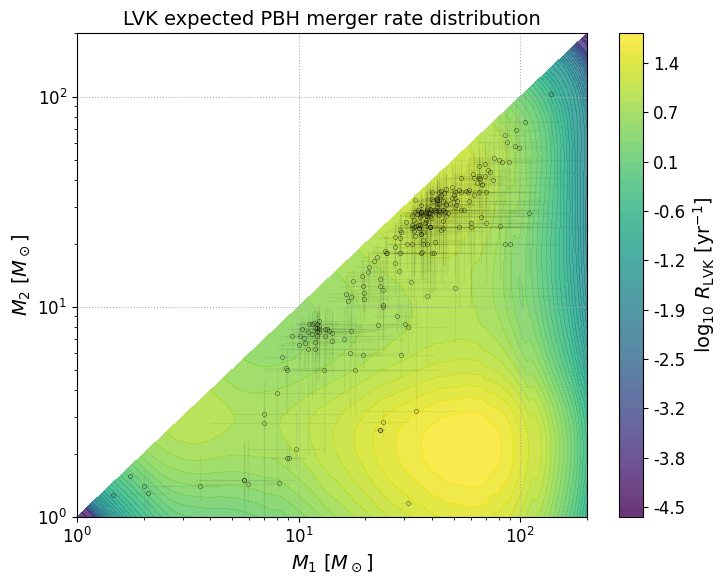

In [ ]:
# Visualize the predicted PBH detection rate in the binary mass plane by plotting
# log10(rate) as filled contours over (M1, M2), and overlay the observed
# gravitational-wave events with their asymmetric uncertainties for direct comparison.

fig, ax = plt.subplots(figsize=(7.5, 6))

n_levels = 50
vmin = np.nanmin(log_rate)
vmax = np.nanmax(log_rate)
levels = np.linspace(vmin, vmax, n_levels)

cf = ax.contourf(M1_grid, M2_grid, log_rate,
                 levels=levels, cmap='viridis', alpha=0.8)

# colorbar, including the floor value
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r'$\log_{10}\,R_{\rm LVK}\,\, [{\rm yr}^{-1}]$')
cbar.formatter = FormatStrFormatter('%.1f')
cbar.update_ticks()

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r"$M_1\ [M_\odot]$")
ax.set_ylabel(r"$M_2\ [M_\odot]$")

ax.set_title(
    rf"LVK expected PBH merger rate distribution"
    #PBH merger rate, $M_1 \geq M_2$, $0.005 \leq q \leq 1$, "
    #rf"${Mc_low:.1f} \leq \mathcal{{M}}_c \leq {Mc_high:.1f}\,M_\odot$"
)
ax.xaxis.label.set_fontsize(14)   
ax.yaxis.label.set_fontsize(14)   
ax.title.set_fontsize(14)        
cbar.ax.yaxis.label.set_fontsize(14)
ax.errorbar(
    M1_evt,
    M2_evt,
    xerr=xerr_evt,
    yerr=yerr_evt,
    fmt='o',
    ecolor=(0, 0, 0, 0.05),    
    capsize=0,
    elinewidth=0.9,
    markerfacecolor='none',
    markeredgecolor=(0, 0, 0, 0.8),
    markeredgewidth=0.3,
    markersize=3,
    zorder=100,
    rasterized=True,
)
ax.grid(True, ls=':')
ax.set_xlim(1,200)
ax.set_ylim(1,200)
plt.tight_layout()
plt.show()

## LISA Detectable event rate

In [ ]:
# Implement the cosmological and PBH-specific ingredients required to compute
# LISA-detectable merger rates in the heavy-mass tail: including distance measures,
# the extended PBH mass function and its number-weighted moments, suppression factors,
# waveform-based SNR modeling, and the integration of the intrinsic merger rate over
# redshift with detector selection effects.


def E_z(z):
    return np.sqrt(Om * (1.0 + z)**3 + Ov)

def Dc_Mpc(z):
    integrand = lambda zz: c_kms / (H0_kms_Mpc * E_z(zz))
    val, _ = quad(integrand, 0.0, z)
    return val

def DL_cm(z):
    Dc = Dc_Mpc(z)
    return (1.0 + z) * Dc * 3.0856776e24

def dVc_dz_Gpc3(z):
    Dc = Dc_Mpc(z)
    dDc_dz = c_kms / (H0_kms_Mpc * E_z(z))
    dVc_dz_Mpc3 = 4.0 * np.pi * Dc**2 * dDc_dz
    return dVc_dz_Mpc3 / 1.0e9  # Gpc^3 per unit z

def cosmic_time_s(z):
    factor = 2.0 / (3.0 * H0 * np.sqrt(Ov))
    arg = np.sqrt(Ov / Om) * (1.0 + z)**(-1.5)
    return factor * np.arcsinh(arg)

t0_s = cosmic_time_s(0.0)

# ============================================================
# PBH MASS FUNCTION INPUT: df_PBH/dlnM FROM FILE
# ============================================================

file_path = "Hasinger.txt" #FA2.txt and Hasinger.txt are ~the same for M > 10^3 
mass_smooth_factor = 1.0

with open(file_path, "r") as f:
    lines = f.read().splitlines()

x = None
y = None
for line in lines:
    if line.lstrip().startswith("x"):
        x = ast.literal_eval(line.split("=", 1)[1])
    elif line.lstrip().startswith("y"):
        y = ast.literal_eval(line.split("=", 1)[1])

if x is None or y is None:
    raise RuntimeError("Could not find x=... and y=... arrays in Hasinger.txt")

x = np.array(x, dtype=float)  # Msun
y = np.array(y, dtype=float)  # df/dlnM

M_cut_adopted = 1e-6
mask = (x > 0) & (y > 0) & (x >= M_cut_adopted)
x_pos, y_pos = x[mask], y[mask]
if x_pos.size < 10:
    raise RuntimeError("Too few points after applying M_cut_adopted=1e-6 Msun.")

spline_log = UnivariateSpline(np.log10(x_pos), np.log10(y_pos), s=mass_smooth_factor)
M_min_adopt, M_max_adopt = x_pos.min(), x_pos.max()

def df_pbh_dlnM(M):
    M = np.asarray(M, dtype=float)
    out = np.zeros_like(M, dtype=float)
    msk = (M >= M_min_adopt) & (M <= M_max_adopt)
    if np.any(msk):
        out[msk] = 10.0 ** spline_log(np.log10(M[msk]))
    return out

# ============================================================
# HEAVY-TAIL-ONLY APPROXIMATION (m in [1e3, 1e8] Msun)
# ============================================================

M_heavy_min = 1e3
M_heavy_max = 1e8

M_heavy_min_eff = max(M_heavy_min, M_min_adopt)
M_heavy_max_eff = min(M_heavy_max, M_max_adopt)
if M_heavy_min_eff >= M_heavy_max_eff:
    raise ValueError("Heavy mass range [1e3,1e8] is outside adopted spline range.")

# Moments on a fine grid
M_grid_mom = np.logspace(np.log10(M_heavy_min_eff), np.log10(M_heavy_max_eff), 12000)
lnM_mom = np.log(M_grid_mom)
df_grid = df_pbh_dlnM(M_grid_mom)

# Heavy-tail mass fraction
fPBH_heavy = simpson(df_grid, x=lnM_mom)

# Number integral: ∫ (df/m) dlnm
I_num_heavy = simpson(df_grid / M_grid_mom, x=lnM_mom)
if I_num_heavy <= 0.0:
    raise RuntimeError("Non-positive heavy-tail ∫(df/m) dlnm.")

# Number-weighted mean mass
mbar_heavy = fPBH_heavy / I_num_heavy

def psi_heavy_number_lnM(M):
    """
    Number-PDF per dlnM, normalized on the heavy tail:
      ψ_heavy(m) = (<m>_heavy / (f_heavy m)) * df/dlnm
    """
    M = np.asarray(M, dtype=float)
    out = np.zeros_like(M, dtype=float)
    msk = (M >= M_heavy_min_eff) & (M <= M_heavy_max_eff)
    if np.any(msk):
        out[msk] = (mbar_heavy / (fPBH_heavy * M[msk])) * df_pbh_dlnM(M[msk])
    return out

psi_grid = psi_heavy_number_lnM(M_grid_mom)
psi_norm = simpson(psi_grid, x=lnM_mom)

m2bar_heavy = simpson((M_grid_mom**2) * psi_grid, x=lnM_mom)
ratio_m2_heavy = m2bar_heavy / (mbar_heavy**2)

# ============================================================
# SUPPRESSION S1 and S2 (APPLIED TO HEAVY TAIL)
# ============================================================

R0 = 1.6e6     # Gpc^-3 yr^-1
sigma_M = 0.004

def C_of_f(f):
    f = float(f)
    if f <= 0.0:
        return 0.0
    xarg = 5.0 * f**2 / (6.0 * sigma_M**2)
    term = (gamma(29.0/37.0) / np.sqrt(np.pi)) * hyperu(21.0/74.0, 0.5, xarg)
    term = float(term)
    if (not np.isfinite(term)) or (term <= 0.0):
        return 0.0
    bracket = (term**(-74.0/21.0)) - 1.0
    if (not np.isfinite(bracket)) or (bracket <= 0.0):
        return 0.0
    return float((f**2) * ratio_m2_heavy / (sigma_M**2) * (1.0 / bracket))

C_const = C_of_f(fPBH_heavy)

def Nbar_of_Mtot(Mtot):
    Mtot = float(Mtot)
    if Mtot <= 0.0:
        return 0.0
    return (Mtot / mbar_heavy) * (fPBH_heavy / (fPBH_heavy + sigma_M))

def S1_of_Mtot(Mtot):
    f = fPBH_heavy
    if f <= 0.0:
        return 0.0
    Nbar = Nbar_of_Mtot(Mtot)
    inside = ratio_m2_heavy * Nbar + C_const + (sigma_M**2) / (f**2)
    if inside <= 0.0:
        return 0.0
    return float(1.42 * (inside**(-21.0/74.0)) * np.exp(-Nbar))

def S2_of_z_array(t_ratio_arr):
    f = fPBH_heavy
    if f <= 0.0:
        return np.zeros_like(t_ratio_arr, dtype=float)
    f_eff = np.maximum((t_ratio_arr**0.44) * f, 1e-50)
    val = 9.6e-3 * (f_eff**(-0.65)) * np.exp(0.03 * (np.log(f_eff)**2))
    return np.minimum(1.0, val)

# ============================================================
# LISA NOISE + INTEGRAL TABLES
# ============================================================

def build_noise_spline(noise_filepath, s=0.0):
    data = np.loadtxt(noise_filepath)
    f, asd = data[:, 0], data[:, 1]
    mask = (f > 0.0) & (asd > 0.0)
    f, asd = f[mask], asd[mask]
    idx = np.argsort(f)
    return UnivariateSpline(np.log10(f[idx]), np.log10(asd[idx]), s=s)

def build_integral_table(noise_spline, fmin, fmax, alpha, n=200000):
    f = np.linspace(fmin, fmax, n)
    asd = 10.0**noise_spline(np.log10(f))
    Sh  = np.clip(asd**2, np.finfo(float).tiny, None)
    integrand = f**(-alpha) / Sh
    df = np.diff(f)
    cum = np.concatenate(([0.0], np.cumsum(0.5 * (integrand[:-1] + integrand[1:]) * df)))
    return f, cum

# ============================================================
# WAVEFORM / SNR (vectorized over z for fixed m1,m2)
# ============================================================

def chirp_mass(m1, m2):
    Mtot = m1 + m2
    return (m1 * m2)**(3.0/5.0) / (Mtot**(1.0/5.0))

def f_isco_Hz(Mtot_solar):
    M_cgs = Mtot_solar * Msun
    M_geom = G_cgs * M_cgs / c_cgs**3  # seconds
    return 1.0 / (6.0**1.5 * np.pi * M_geom)

def f_merge_Hz(m1, m2):
    """
    Source-frame merger frequency from Ajith et al. (2008):
        pi M_tot f_merge = a0 eta^2 + b0 eta + c0
    with M_tot in geometric units and eta the symmetric mass ratio.
    """
    m1 = float(m1)
    m2 = float(m2)
    Mtot = m1 + m2
    if Mtot <= 0.0:
        return 0.0

    eta = (m1 * m2) / (Mtot**2)
    M_geom = G_cgs * (Mtot * Msun) / c_cgs**3  # seconds

    a0 = 6.6389e-1
    b0 = -1.0321e-1
    c0 = 1.0979e-1

    return (a0 * eta**2 + b0 * eta + c0) / (np.pi * M_geom)

def f_start_Hz_vec(Mc_z_geom, Tobs_yr):
    Tobs_s = Tobs_yr * SEC_PER_YR
    factor = (5.0 / 256.0) * (Mc_z_geom**(-5.0/3.0)) / Tobs_s
    return (factor**(3.0/8.0)) / np.pi

def snr_lisa_over_z(m1, m2, z_arr, DL_geom_arr,
                    f1_grid, cum1, f2_grid, cum2,
                    fmin_LISA, fmax_LISA,
                    Tobs_yr=4.0):
    Mtot = m1 + m2
    if Mtot <= 0.0:
        return np.zeros_like(z_arr, dtype=float)

    Mc_solar = chirp_mass(m1, m2)
    Mc_geom  = G_cgs * (Mc_solar * Msun) / c_cgs**3  # seconds

    # Source-frame transition frequencies
    f_isco_src  = f_isco_Hz(Mtot)
    f_merge_src = f_merge_Hz(m1, m2)

    # Detector-frame frequencies
    f_split = np.minimum(f_isco_src / (1.0 + z_arr), fmax_LISA)
    f_high  = np.minimum(f_merge_src / (1.0 + z_arr), fmax_LISA)

    Mc_z_geom = Mc_geom * (1.0 + z_arr)
    f_start = f_start_Hz_vec(Mc_z_geom, Tobs_yr)
    f_low = np.maximum(fmin_LISA, f_start)

    rho = np.zeros_like(z_arr, dtype=float)

    # Need at least some band in the detector frame
    ok = f_high > f_low
    if not np.any(ok):
        return rho

    idx_ok = np.where(ok)[0]

    f_low_ok   = f_low[idx_ok]
    f_split_ok = f_split[idx_ok]
    f_high_ok  = f_high[idx_ok]

    # Inspiral piece: [f_low, min(f_split, f_high)]
    I1_upper = np.minimum(f_split_ok, f_high_ok)
    I1 = np.zeros_like(I1_upper)
    use1 = I1_upper > f_low_ok
    if np.any(use1):
        I1_hi = np.interp(I1_upper[use1], f1_grid, cum1)
        I1_lo = np.interp(f_low_ok[use1],   f1_grid, cum1)
        I1[use1] = I1_hi - I1_lo

    # Post-inspiral piece: [max(f_low, f_split), f_high]
    I2_lower = np.maximum(f_low_ok, f_split_ok)
    I2 = np.zeros_like(I2_lower)
    use2 = f_high_ok > I2_lower
    if np.any(use2):
        I2_hi = np.interp(f_high_ok[use2],  f2_grid, cum2)
        I2_lo = np.interp(I2_lower[use2],   f2_grid, cum2)
        I2[use2] = I2_hi - I2_lo

    Itot = I1 + I2

    goodI = Itot > 0.0
    if not np.any(goodI):
        return rho

    idx_good = idx_ok[goodI]
    pref = (2.0 / 3.0) * (np.pi**(-4.0/3.0))
    rho2 = pref * (Mc_z_geom[idx_good]**(5.0/3.0)) * Itot[goodI] / (DL_geom_arr[idx_good]**2)
    rho[idx_good] = np.sqrt(np.maximum(rho2, 0.0))
    return rho

# ============================================================
# PER-(M1,M2) DETECTED RATE IN A REDSHIFT BIN
# ============================================================

def detected_rate_lisa_pair_in_bin(
    m1, m2,
    z_arr, dz,
    DL_geom_arr, t_ratio_arr,
    dVc_shell_arr,  # already includes dz/(1+z)
    f1_grid, cum1, f2_grid, cum2,
    fmin_LISA=1e-4, fmax_LISA=1.0,
    rho_thr=9.0,
    Tobs_yr=4.0,
    dlnM=0.1
):
    # Enforce only physical
    Mtot = m1 + m2
    if Mtot <= 0.0:
        return 0.0
    eta = (m1 * m2) / (Mtot**2)
    if eta <= 0.0:
        return 0.0

    # Suppression S1 (mass-dependent)
    S1 = S1_of_Mtot(Mtot)
    if S1 <= 0.0:
        return 0.0

    # S2(z) (already via t_ratio_arr)
    S2_arr = S2_of_z_array(t_ratio_arr)

    # Raidal prefactor pieces that depend on z
    z_pref = R0 * (fPBH_heavy**(53.0/37.0)) * (t_ratio_arr**(-34.0/37.0)) * S2_arr

    # Mass-dependent Raidal pieces
    mass_pref = (Mtot**(-32.0/37.0)) * (eta**(-34.0/37.0)) * S1

    # Mass-function factor (heavy-tail number-PDF)
    psi1 = float(psi_heavy_number_lnM(np.array([m1]))[0])
    psi2 = float(psi_heavy_number_lnM(np.array([m2]))[0])
    if psi1 <= 0.0 or psi2 <= 0.0:
        return 0.0

    # dm1 dm2 = m1 m2 dlnm1 dlnm2
    mf_measure = (psi1 * psi2 / (mbar_heavy**2)) * (m1 * m2) * (dlnM * dlnM)

    # SNR selection over z
    rho_arr = snr_lisa_over_z(
        m1, m2, z_arr, DL_geom_arr,
        f1_grid, cum1, f2_grid, cum2,
        fmin_LISA, fmax_LISA,
        Tobs_yr=Tobs_yr
    )
    sel = rho_arr >= rho_thr
    if not np.any(sel):
        return 0.0

    # Rate contribution from this mass cell integrated over z in the bin
    # dVc_shell_arr already includes dz/(1+z)
    return mf_measure * mass_pref * np.sum(z_pref[sel] * dVc_shell_arr[sel])  # yr^-1


# ============================================================
# DIAGNOSTICS
# ============================================================

print("=== HEAVY-TAIL SETUP CHECK ===")
print(f"Adopted spectrum lower cut: {M_cut_adopted:.3e} Msun")
print(f"Adopted spline range: [{M_min_adopt:.3e}, {M_max_adopt:.3e}] Msun")
print(f"Heavy-tail range used: [{M_heavy_min_eff:.3e}, {M_heavy_max_eff:.3e}] Msun")
print("f_PBH_heavy =", fPBH_heavy)
print("psi_heavy norm check =", psi_norm)
print("<m>_heavy (Msun) =", mbar_heavy)
print("<m^2>/<m>^2 (heavy) =", ratio_m2_heavy)
print("C(f_PBH_heavy) =", C_const)

=== HEAVY-TAIL SETUP CHECK ===
Adopted spectrum lower cut: 1.000e-06 Msun
Adopted spline range: [1.463e-06, 6.698e+09] Msun
Heavy-tail range used: [1.000e+03, 1.000e+08] Msun
f_PBH_heavy = 0.00024335528066801005
psi_heavy norm check = 0.9999999999999999
<m>_heavy (Msun) = 3330.4774052283774
<m^2>/<m>^2 (heavy) = 142.40114396192976
C(f_PBH_heavy) = 3.431095156044724


#### Figure

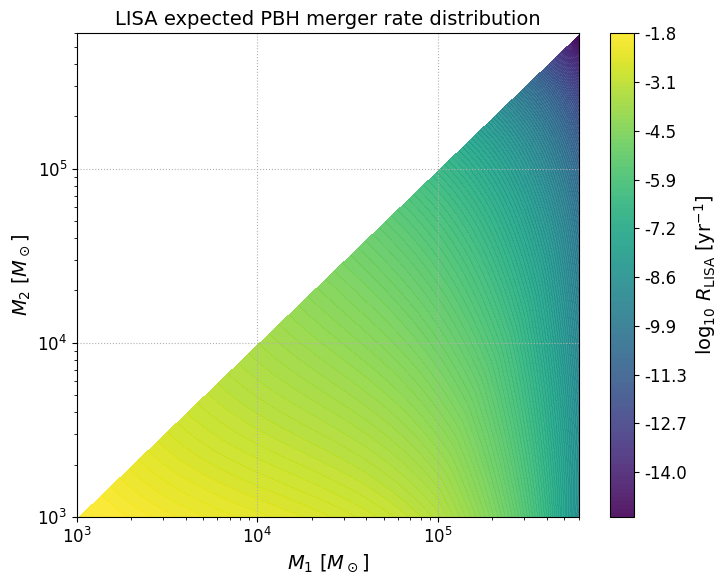

(array([[           nan, 1.53234716e-02, 1.54735736e-02, ...,
         3.61794686e-09, 2.30701315e-09, 1.23047205e-09],
        [           nan,            nan, 1.56569734e-02, ...,
         3.80531226e-09, 2.45684466e-09, 1.35895221e-09],
        [           nan,            nan,            nan, ...,
         3.96271104e-09, 2.58433478e-09, 1.47034619e-09],
        ...,
        [           nan,            nan,            nan, ...,
                    nan, 1.10743950e-15, 7.70208467e-16],
        [           nan,            nan,            nan, ...,
                    nan,            nan, 5.40947188e-16],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]),
 array([[         nan,  -1.81464283,  -1.81040938, ...,  -8.44153782,
          -8.63694993,  -8.90992825],
        [         nan,          nan,  -1.80529218, ...,  -8.4196097 ,
          -8.6096223 ,  -8.86679582],
        [         nan,          nan,          nan

In [ ]:
# ============================================================
# MAKE THE (M1,M2) HALF-PLANE PLOT FOR LISA
# ============================================================

def make_lisa_massplane_plot(
    noise_filepath="LISA_ASD.txt",
    fmin_LISA=1e-4, fmax_LISA=1.0,
    rho_thr=9.0,
    Tobs_yr=4.0,
    z_min=5.0, z_max=20.0,
    M1_min=1e3, M1_max=1e8,
    M2_min=1e3, M2_max=1e8,
    n_M=180,
    n_z=220
):
    # Noise spline + two integral tables
    noise_spline = build_noise_spline(noise_filepath, s=0.0)
    f1_grid, cum1 = build_integral_table(noise_spline, fmin_LISA, fmax_LISA, alpha=7.0/3.0, n=30000)
    f2_grid, cum2 = build_integral_table(noise_spline, fmin_LISA, fmax_LISA, alpha=2.0/3.0, n=30000)

    # Redshift grid and cosmological arrays
    z_arr = np.linspace(z_min, z_max, n_z)
    dz = z_arr[1] - z_arr[0] if n_z > 1 else (z_max - z_min)

    DL_geom_arr = np.array([DL_cm(z)/c_cgs for z in z_arr], dtype=float)  # seconds
    t_ratio_arr = np.array([cosmic_time_s(z)/t0_s for z in z_arr], dtype=float)

    # dVc_shell already includes dz/(1+z)
    dVc_shell_arr = (np.array([dVc_dz_Gpc3(z) for z in z_arr], dtype=float) * dz) / (1.0 + z_arr)

    # Mass grids (log-spaced)
    logM1 = np.linspace(np.log10(M1_min), np.log10(M1_max), n_M)
    logM2 = np.linspace(np.log10(M2_min), np.log10(M2_max), n_M)
    M1_vals = 10.0**logM1
    M2_vals = 10.0**logM2
    M1_grid, M2_grid = np.meshgrid(M1_vals, M2_vals, indexing="xy")

    # Use the grid spacing as the effective dlnM bin width (constant)
    dlnM = np.log(M1_vals[1]) - np.log(M1_vals[0])

    # Compute rate grid, but only for M1 > M2 (half-plane)
    rate_grid = np.full_like(M1_grid, np.nan, dtype=float)

    for i in range(M2_grid.shape[0]):
        for j in range(M1_grid.shape[1]):
            m1 = float(M1_grid[i, j])
            m2 = float(M2_grid[i, j])

            if m1 <= m2:
                continue

            # Only within the heavy-tail support (otherwise zero)
            if (m1 < M_heavy_min_eff) or (m1 > M_heavy_max_eff) or (m2 < M_heavy_min_eff) or (m2 > M_heavy_max_eff):
                rate_grid[i, j] = 0.0
                continue

            rate_grid[i, j] = detected_rate_lisa_pair_in_bin(
                m1, m2,
                z_arr, dz,
                DL_geom_arr, t_ratio_arr,
                dVc_shell_arr,
                f1_grid, cum1, f2_grid, cum2,
                fmin_LISA=fmin_LISA, fmax_LISA=fmax_LISA,
                rho_thr=rho_thr,
                Tobs_yr=Tobs_yr,
                dlnM=dlnM
            )

            
    # ============================================================
    # CUMULATIVE RATE IN A SELECTED MASS BOX, DECOMMENT IF NEEDED
    # ============================================================

    #M1_sel_min, M1_sel_max = 1e4, 1e5
    #M2_sel_min, M2_sel_max = 1e4, 1e5

    #mask = (
    #    (M1_grid >= M1_sel_min) & (M1_grid <= M1_sel_max) &
    #    (M2_grid >= M2_sel_min) & (M2_grid <= M2_sel_max)
    #)

    #rate_box = np.nansum(rate_grid[mask])

    #print(
    #    f"Cumulative LISA rate for "
    #    f"M1=[{M1_sel_min:.1e},{M1_sel_max:.1e}] Msun, "
    #    f"M2=[{M2_sel_min:.1e},{M2_sel_max:.1e}] Msun, "
    #    f"z=[{z_min},{z_max}]: {rate_box:.3e} yr^-1"
    #)



    # Log transform with a floor for zeros (inside computed region)
    log_rate = np.full_like(rate_grid, np.nan, dtype=float)
    valid = np.isfinite(rate_grid)

    pos = valid & (rate_grid > 0.0)
    if np.any(pos):
        log_rate[pos] = np.log10(rate_grid[pos])
        log_min_pos = np.nanmin(log_rate[pos])
        log_floor = log_min_pos - 1.0
        zero = valid & (rate_grid == 0.0)
        log_rate[zero] = log_floor
    else:
        log_floor = -99.0
        log_rate[valid] = log_floor

    # Plot
    fig, ax = plt.subplots(figsize=(7.5, 6.0))

    vmin = np.nanmin(log_rate)
    vmax = np.nanmax(log_rate)
    levels = np.linspace(vmin, vmax, 120)

    cf = ax.contourf(M1_grid, M2_grid, log_rate, levels=levels, cmap="viridis", alpha=0.9)
    cbar = fig.colorbar(cf, ax=ax)
    cbar.set_label(r'$\log_{10}\,R_{\rm LISA} \,\,[{\rm yr}^{-1}]$')
    cbar.formatter = FormatStrFormatter('%.1f')
    cbar.update_ticks()

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$M_1\ [M_\odot]$")
    ax.set_ylabel(r"$M_2\ [M_\odot]$")
    ax.set_title(rf"LISA expected PBH merger rate distribution")

    ax.grid(True, ls=":")
    ax.set_xlim(M1_min, M1_max)
    ax.set_ylim(M2_min, M2_max)

    ax.xaxis.label.set_fontsize(14)
    ax.yaxis.label.set_fontsize(14)
    ax.title.set_fontsize(14)
    cbar.ax.yaxis.label.set_fontsize(14)

    plt.tight_layout()
    plt.show()

    return rate_grid, log_rate


make_lisa_massplane_plot(
        noise_filepath="LISA_ASD.txt",
        fmin_LISA=1e-4,
        fmax_LISA=1.0,
        rho_thr=9.0,
        Tobs_yr=4.0,
        z_min=5.0,
        z_max=20.0,
        M1_min=1e3,
        M1_max=6e5,
        M2_min=1e3,
        M2_max=6e5,
        n_M=200,
        n_z=220
    )